In [1]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


tensor([0, 1, 2,  ..., 2, 4, 2], device='cuda:0')

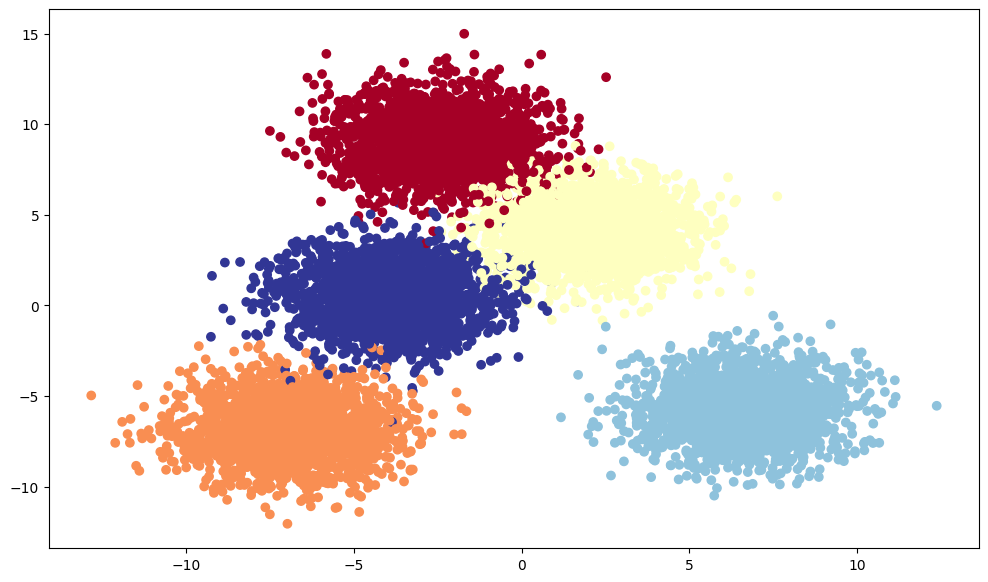

In [2]:
import torch
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

n_samples = 10000
n_classes = 5
random_seed = 42
n_features = 4

# Creating data
X_blob, y_blob = make_blobs(n_samples=n_samples, n_features=n_features, centers=n_classes, cluster_std=1.55, random_state=random_seed )

# Data to Tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.long)


X_blob[:10]
# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X_blob,
                                                    y_blob,
                                                    test_size=0.2,
                                                    random_state=random_seed, stratify=y_blob)

# Plotting data
plt.figure(figsize=(12,7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)

X_train.to(device)
X_test.to(device)
y_train.to(device)
y_test.to(device)

#### Building Multiclass model

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
torch.cuda.is_available()

True

In [5]:
from torch import nn

class MulticlassModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=10):
        """ 
        Initializes the multiclass model.
        """

        super().__init__()
        self.layer_1 = nn.Linear(input_features, hidden_units)
        self.layer_2 = nn.Linear(hidden_units, hidden_units)
        self.layer_3 = nn.Linear(hidden_units, output_features)
        self.relu = nn.ReLU()

    def forward(self, x):
        """ 
        Sequential forward pass through the layers in the model.
        """
        model = nn.Sequential(self.layer_1,
                              self.relu,
                              self.layer_2,
                              self.relu,
                              self.layer_3)
        return model(x)
    
model = MulticlassModel(input_features=n_features, output_features=n_classes).to(device)

model.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.3143,  0.4325,  0.3027, -0.1463],
                      [ 0.3901,  0.1658,  0.2963,  0.2586],
                      [ 0.4883, -0.4708,  0.3580,  0.2393],
                      [-0.2239,  0.4253, -0.3926,  0.4193],
                      [-0.3040, -0.1845,  0.1540, -0.2641],
                      [ 0.4006, -0.4771,  0.0135,  0.2566],
                      [-0.2496,  0.1665, -0.0286, -0.3462],
                      [ 0.4235,  0.0487, -0.4798, -0.0933],
                      [-0.0848,  0.1859, -0.0946,  0.2709],
                      [ 0.3383,  0.1300, -0.2822, -0.2283]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.0962,  0.2959,  0.3811, -0.1359,  0.1996, -0.0902,  0.0055, -0.1787,
                       0.0758, -0.1027], device='cuda:0')),
             ('layer_2.weight',
              tensor([[-0.1537, -0.2951, -0.0673,  0.1948, -0.0907, -0.0666, -0.1793, -0.0453,
                       -0.0029, -0.22

In [6]:
X_train.shape, y_train.shape

(torch.Size([8000, 4]), torch.Size([8000]))

#### Training Model


In [7]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1, momentum=0.9)

In [8]:
preds = model(X_train.to(device))
preds

tensor([[-0.4502,  0.0133,  0.0271, -0.6678,  0.6185],
        [ 0.2571, -0.3132, -0.5661, -0.9021,  0.2916],
        [-0.1680,  0.2229, -0.2988, -1.6985,  0.4058],
        ...,
        [ 0.1585,  0.2881, -0.3186, -0.8691,  0.4193],
        [ 0.4842, -0.7210, -0.7693, -1.1471,  0.2637],
        [-0.4089,  0.2910,  0.0970, -0.4886,  0.4374]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

In [9]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [10]:
def train_model(model: nn.Module,
                data: torch.Tensor, 
                targets: torch.Tensor,
                test_data: torch.Tensor,
                test_labels: torch.Tensor,
                optimizer,
                loss_fn,
                Epochs):

    """ 
    
    """

    torch.manual_seed(random_seed)
    torch.cuda.manual_seed(random_seed)

    for epoch in range(Epochs):
        model.train()

        # 1. Forward pass
        y_logits = model(data.to(device))
        y_preds = torch.softmax(y_logits, dim=1).argmax(dim=1)
        # 2. Calculate the loss
        loss = loss_fn(y_logits, targets.to(device))
        accuracy = accuracy_fn(targets, y_preds)
        # 
        optimizer.zero_grad()

        # 3. Backpropagtion 
        loss.backward()

        # 4. Optimizer step
        optimizer.step()

        ## Testing
        model.eval()
        with torch.inference_mode():
            y_test_logits = model(test_data.to(device))
            y_test_preds = torch.softmax(y_test_logits, dim=1).argmax(dim=1)
            test_loss = loss_fn(y_test_logits, test_labels)
            test_accuracy = accuracy_fn(test_labels, y_test_preds)

        if epoch % 50 == 0:
            print(f'Epoch: {epoch} | Loss: {loss:.4f} | Train Accuracy: {accuracy:.2f}% | Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%')


In [11]:
Epochs = 1000
train_model(model=model, data=X_train, targets=y_train, test_data=X_test, test_labels=y_test, optimizer=optimizer, loss_fn=loss_fn, Epochs=Epochs)

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [12]:
model.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.3143,  0.4325,  0.3027, -0.1463],
                      [ 0.3901,  0.1658,  0.2963,  0.2586],
                      [ 0.4883, -0.4708,  0.3580,  0.2393],
                      [-0.2239,  0.4253, -0.3926,  0.4193],
                      [-0.3040, -0.1845,  0.1540, -0.2641],
                      [ 0.4006, -0.4771,  0.0135,  0.2566],
                      [-0.2496,  0.1665, -0.0286, -0.3462],
                      [ 0.4235,  0.0487, -0.4798, -0.0933],
                      [-0.0848,  0.1859, -0.0946,  0.2709],
                      [ 0.3383,  0.1300, -0.2822, -0.2283]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.0962,  0.2959,  0.3811, -0.1359,  0.1996, -0.0902,  0.0055, -0.1787,
                       0.0758, -0.1027], device='cuda:0')),
             ('layer_2.weight',
              tensor([[-0.1537, -0.2951, -0.0673,  0.1948, -0.0907, -0.0666, -0.1793, -0.0453,
                       -0.0029, -0.22

In [13]:
model.eval()
with torch.inference_mode():
    y_logits = model(X_test)
    y_probs = torch.softmax(y_logits, dim=1)
    loss = loss_fn(y_logits, y_test)


print(y_probs)
print(loss)

RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA_addmm)

In [ ]:
## from pred_prob to labels
y_preds = torch.argmax(y_probs, dim=1)
print(y_preds[:10])
print(y_test[:10])

### Saving Model


In [ ]:
from pathlib import Path


MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = '03_PYTORCH_MULTICLASS_MODEL.pth'
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f'Model saved to: {MODEL_SAVE_PATH}')
torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)


### Loading and Testing Saved model


In [ ]:
load_model = MulticlassModel(input_features=n_features, output_features=n_classes)

load_model.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

load_model.state_dict()

In [ ]:
## Testing model

load_model.eval()
with torch.inference_mode():
    y_logits = load_model(X_test.to(device))
    y_probs = torch.softmax(y_logits, dim=1)
    y_preds = torch.argmax(y_probs, dim=1)
    test_loss = loss_fn(y_logits, y_test)
    test_accuracy = accuracy_fn(y_preds, y_test)

print(f'Model Test Loss: {test_loss} | Test Accuracy: {test_accuracy:.2f}%')



In [ ]:
import numpy as np

def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y."""
    
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Use first 2 features for visualization
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Create input with all features (use mean of remaining features)
    X_to_pred_on = np.column_stack((xx.ravel(), yy.ravel()))
    
    # If data has more than 2 features, append mean values of other features
    if X.shape[1] > 2:
        for i in range(2, X.shape[1]):
            X_to_pred_on = np.column_stack((X_to_pred_on, np.full(X_to_pred_on.shape[0], X[:, i].mean().item())))
    
    X_to_pred_on = torch.from_numpy(X_to_pred_on).float()

    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))

    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

In [ ]:
X_test.shape, y_test.shape

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(load_model, X_test, y_test)


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

precision = precision_score(y_test, y_preds, average='macro')
print(f'Precision Score: {precision}')

recall = recall_score(y_test, y_preds, average='macro')
print(f'Recall Score: {recall}')

f1_score = f1_score(y_test, y_preds, average='macro')
print(f'F1 Score: {f1_score}')

report = classification_report(y_test, y_preds)
print(f'Classification Report: {report}')
